# **06 토픽 모델(Topic Modeling) - 20 뉴스그룹**

In [23]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 의학, 우주 주제를 추출.
cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
        'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med'  ]

# 위에서 cats 변수로 기재된 category만 추출. featch_20newsgroups( )의 categories에 cats 입력
news_df= fetch_20newsgroups(subset='all',remove=('headers', 'footers', 'quotes'),
                            categories=cats, random_state=0)

#LDA는 Count 기반의 Vectorizer만 적용합니다.
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english', ngram_range=(1,2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [25]:
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [26]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

In [27]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #',topic_index)

        # components_ array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array index를 반환.
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes=topic_word_indexes[:no_top_words]

        # top_indexes대상인 index별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
        feature_concat = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)

# CountVectorizer객체내의 전체 word들의 명칭을 get_features_names( )를 통해 추출
feature_names = count_vect.get_feature_names_out()

# Topic별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


# **07 문서 군집화 소개와 실습(Opinion Review 데이터 세트)**

**Opinion Review 데이터 세트를 이용한 문서 군집화 수행하기**

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

path = '/content/drive/MyDrive/Opinosis/topics'
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []

for file_ in all_files:
    # 경로에서 파일명만 추출
    filename = os.path.basename(file_).split('.')[0]

    with open(file_, 'r', encoding='latin1') as f:
        content = f.read()

    filename_list.append(filename)
    opinion_text.append(content)

# DataFrame 생성
document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})

# 파일명 기준 정렬
document_df = document_df.sort_values(by='filename').reset_index(drop=True)

# 출력
document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .\n It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .\n I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS .\n It got me from point A to point B with 100% accuracy everytime .\n It has yet to disappoint, getting me everywhere with 100% a..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n Large comfortable room, wonderful bathroom .\n The rooms were nice, very comfy bed and very clean bathroom .\n Bathroom was spacious too and very clean .\n The bathroom only had a single sink, but it was very large .\n The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember .\nThe room was quite small but perfectly formed with a super bathroom .\n You could eat off the bathroom floor it was so clean .\n The ba..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 .\n After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out .\nThe fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me .\n Things like the buttons that made it easy to accidentally tur..."
3,battery-life_ipod_nano_8gb,"short battery life I moved up from an 8gb .\nI love this ipod except for the battery life .\n long battery scratch resistant\n Battery drains even if I don't use it .\n I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down .\n great in the car, light, portable, good quality, long battery,scratch resistant .\n5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for..."
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery .\n It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 .\n3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 .\n Realistic battery numbers are between 8 .\n of battery life if you're using wifi & doing email word processing YouTube web surfing .\n The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n A few other things I'd like to point out is that you must push the micro, sized..."


In [56]:
from nltk.stem import WordNetLemmatizer
import nltk
import string

remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 입력으로 들어온 token단어들에 대해서 lemmatization 어근 변환.
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# TfidfVectorizer 객체 생성 시 tokenizer인자로 해당 함수를 설정하여 lemmatization 적용
# 입력으로 문장을 받아서 stop words 제거-> 소문자 변환 -> 단어 토큰화 -> lemmatization 어근 변환.
def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

In [57]:
import nltk
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english' , \
                             ngram_range=(1,2), min_df=0.05, max_df=0.85 )

#opinion_text 컬럼값으로 feature vectorization 수행
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [58]:
from sklearn.cluster import KMeans

# 5개 집합으로 군집화 수행. 예제를 위해 동일한 클러스터링 결과 도출용 random_state=0
km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

In [59]:
document_df['cluster_label'] = cluster_label
document_df.head()

,filename,opinion_text,cluster_label
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .\n It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .\n I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS .\n It got me from point A to point B with 100% accuracy everytime .\n It has yet to disappoint, getting me everywhere with 100% a...",2
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n Large comfortable room, wonderful bathroom .\n The rooms were nice, very comfy bed and very clean bathroom .\n Bathroom was spacious too and very clean .\n The bathroom only had a single sink, but it was very large .\n The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember .\nThe room was quite small but perfectly formed with a super bathroom .\n You could eat off the bathroom floor it was so clean .\n The ba...",1
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 .\n After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out .\nThe fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me .\n Things like the buttons that made it easy to accidentally tur...",4
3,battery-life_ipod_nano_8gb,"short battery life I moved up from an 8gb .\nI love this ipod except for the battery life .\n long battery scratch resistant\n Battery drains even if I don't use it .\n I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down .\n great in the car, light, portable, good quality, long battery,scratch resistant .\n5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for...",4
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery .\n It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 .\n3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 .\n Realistic battery numbers are between 8 .\n of battery life if you're using wifi & doing email word processing YouTube web surfing .\n The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n A few other things I'd like to point out is that you must push the micro, sized...",4


In [60]:
document_df[document_df['cluster_label']==0].sort_values(by='filename')

,filename,opinion_text,cluster_label
5,buttons_amazon_kindle,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it .\n As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately !\nAfter reading through the introductory guide that loads up automatically at the start and following along it took me almost no time to learn which buttons are where and what each of them do .\n I started reading with the default size without my glasses and noticed I was squinting a bit, so changed to one size larger with a couple button clicks and it was much easier without feeling like the print was too big and took up too...",0
10,eyesight-issues_amazon_kindle,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes .\n the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page .\n The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and facilitate quick easy downloads, and be as portable, as easy on the eyes, and as intuitive as a book .\n they would ask, to which I would squint my eyes and reply, Huh ?\n I found that the Kindle 2 is immediately appealing to the eye and once described in the barest of terms people want one for themselves .\n No having to turn away every few minutes to relax your eyes or en...",0
12,fonts_amazon_kindle,"Being able to change the font sizes is awesome !\n For whatever reason, Amazon decided to make the Font on the Home Screen than on the K1 .\n I found myself constantly changing the angle of the body, changing the font size up and down and the distance away from me .\n I was an avid reader but increasing age has made printed books more of a challenge, but the Kindle with its varying font size and very light weight has made reading fun again .\n What's more, it's easy to change font size .\n The kindle does not recognize page numbers, since they would change radically when you change font size so Amazon provides the notion of location which is display independent .\n I just crank the fo...",0
23,navigation_amazon_kindle,"In fact, the entire navigation structure has been completely revised , I'm still getting used to it but it's a huge step forward .\nNavigation is a huge improvement .\n Clearly, Amazon was hard at work to make navigation quicker and easier .\n I tried out the free 14 day trial on newspaper downloads, what a great way to get your news, no advertising distractions, easy to navigate and automatically downloaded every day .\n Once I got used to it, the navigation was easy too .\n The Sony store is cumbersome to navigate, and slow .\nDespite the lighter text, I prefer the K2 for its thinness and its improved navigation and I use if far more than my K1 .\n On the Kindle, you have wireless d...",0
27,price_amazon_kindle,"If a case was included, as with the Kindle 1, that would have been reflected in a higher price .\n lower overall price, with nice leather cover .\nIf you have the first Kindle and are deciding whether to upgrade, do it now while you can still get a good price for your old Kindle on Amazon's Marketplace, craigslist, wherever .\n Before purchasing, I was obsessed with the reviews and predictions I found online and reading about some of the critiques such as the thick border, the lack of touchscreen, lack of battery SD slot, lack of a back light, awkward difficult keyboard layout, minimally faster page flipping, and the super, high price .\n However, I think all the positives of the K2 gre...",0
28,price_holiday_inn_london,"All in all, a normal chain hotel on a nice location , I will be back if I do not find anthing closer to Picadilly for a better price .\nGreat Price Terrific Location .\nOur main focus before booking was looking for a low price with good location .\n All for the bargain price off £ 250 for 2 nights

In [61]:
document_df[document_df['cluster_label']==1].sort_values(by='filename')

,filename,opinion_text,cluster_label
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n Large comfortable room, wonderful bathroom .\n The rooms were nice, very comfy bed and very clean bathroom .\n Bathroom was spacious too and very clean .\n The bathroom only had a single sink, but it was very large .\n The room was a standard but nice motel room like any other, bathroom seemed upgraded if I remember .\nThe room was quite small but perfectly formed with a super bathroom .\n You could eat off the bathroom floor it was so clean .\n The ba...",1
13,food_holiday_inn_london,"The room was packed to capacity with queues at the food buffets .\n The over zealous staff cleared our unfinished drinks while we were collecting cooked food and movement around the room with plates was difficult in the crowded circumstances .\n There are a couple pubs, a great patisserie and even fast food restaurants within a block .\nThe neighborhood is an upscale residential area full of restaurants in easy walking distance ranging from fast food to up, scale with a wide variety of cuisines , , we never had a bad meal .\nThe food was wonderful, a selection of sandwiches, salads, cous cous and spicy wedge potato's, fruit salad and a cake was a good fill up when needed .\nFull ...",1
14,food_swissotel_chicago,"The food for our event was delicious .\n The food in the lounge was great and very fresh, , , salads, sandwiches etc .\n As far as food, walk a few blocks toward Michigan Ave turn left or right and there are plently of less expensive places to eat .\n The Palm resturant in the hotel had some specials Sunday night, we ate there and the food service,etc were outstanding portions are large and we shared since we are not big eaters .\n Took the charge of the minibar which we had used to keep my 2 year old sons food .\n We never ate anything onsite so I can't vouch for the food options immediately avialable .\n The Lobby bar does not serve food very late at night and we couldn't find any ven...",1
15,free_bestwestern_hotel_sfo,"The wine reception is a great idea as it is nice to meet other travellers and great having access to the free Internet access in our room .\n They also have a computer available with free internet which is a nice bonus but I didn't find that out till the day before we left but was still able to get on there to check our flight to Vegas the next day .\n The service was good, very friendly staff and we loved the free wine reception each night .\n has free wireless and help you with transportation needs .\n The nightly free wine tasting from 5 , 6 pm is a brilliant idea and gets guests together to socialise witheach other .\n They have a happy hour where you have a couple offree drinks bet...",1
20,location_bestwestern_hotel_sfo,"Good Value good location , ideal choice .\nGreat Location , Nice Rooms , Helpless Concierge\n The location is good, and the overall decor is nice, but there was nothing that I can really rave about .\n Overall, it was a good location, but an average hotel with serious noise issues .\nA perfect hotel a perfect location perfect staff !\n The location is perfect to pier 39 and surrounding areas .\n My husband found this hotel on Trip Advisor and it ranked very high and we weren't disappointed at all as it is in a great location and a very nice hotel .\nThe hotel location was perfect .\nMy husband and I stayed for two nights at the Tuscan Inn and enjoyed it's great location to Fisherman...",1
21,location_holiday_inn_london,"Great location for tube and we crammed in a fair amount of sightseeing in a short time .\nAll in all, a normal chain hotel on a nice location , I will be back if I do not find anthing closer to Picadilly for a better price .\nGreat Price Terrific Location .\nThe location is ab

In [62]:
document_df[document_df['cluster_label']==2].sort_values(by='filename')

,filename,opinion_text,cluster_label
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .\n It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .\n I've used other GPS units, as well as GPS built into cars and to this day NOTHING beats the accuracy of a Garmin GPS .\n It got me from point A to point B with 100% accuracy everytime .\n It has yet to disappoint, getting me everywhere with 100% a...",2
8,directions_garmin_nuvi_255W_gps,"You also get upscale features like spoken directions including street names and programmable POIs .\n I used to hesitate to go out of my directions but not any more .\n the directions didn't tell me anything I didn't already know after fiddling with it for 10 minutes .\n It also does not offer an option to view the route as a series of turn by turn directions .\n It gives your heading not in terms of degres but only in terms of one of eight directions .\nThe widescreen is a plus and I highly recommend it, even though it has the wide screen you can stick it in your back pocket which can be conveniently used for walking directions .\nGarmin's nuvi 255W is a handy little device that pr...",2
9,display_garmin_nuvi_255W_gps,"3 quot widescreen display was a bonus .\n This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n I also found that the display on the 255w was a bit brighter, clearer, and more vivid than on the 750 in both daylight and at night .\n The 750 just displays text on the top line for upcoming turns without the arrow .\n The 255 also automatically adjusts the font size of displayed text so that even lengthy text will fit .\nAnother feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\nThe 255W has a really clear di...",2
19,keyboard_netbook_1005ha,", I think the new keyboard rivals the great hp mini keyboards .\nSince the battery life difference is minimum, the only reason to upgrade would be to get the better keyboard .\n The keyboard is now as good as the HP and Samsung netbooks .\n The keyboards are 92% the size of those found on a standard computer and the machines run a little hot .\n The keyboard is large enough to accommodate touch typing with ease .\n At home I now have my Asus connected to my desktop's keyboard and monitor .\n However, since I do a lot of word processing, the keyboard and the touchpad buttons were a real concern .\n The keyboard has a responsive feel and the larger keys along with the oversize right shi...",2
33,satellite_garmin_nuvi_255W_gps,"It's fast to acquire satellites .\n If you've ever had a Brand X GPS take you on some strange route that adds 20 minutes to your trip, has you turn the wrong way down a one way road, tell you to turn AFTER you've passed the street, frequently loses the satellite signal, or has old maps missing streets, you know how important this stuff is .\n The Garmin Nuvi 255W connects to satellites extremely fast, , So when I get in my car and turn it on, we're pretty much ready to go immediately .\nIt picks up the satellites quickly , routes fast, has good animation maybe 6, 8 frames a second ?\n The revised chipset allows the GPS to make satellite connections quickly .\n The unit takes very qui...",2
34,screen_garmin_nuvi_255W_gps,"It is easy to read and when touching the screen it works great !\n and zoom out buttons on the 255w to the same side of the screen which makes it a bit easier .\n On the 750 the zoom buttons are on opposite sides of the screen .\n The screen is easily readable in the su

In [63]:
document_df[document_df['cluster_label']==3].sort_values(by='filename')

,filename,opinion_text,cluster_label
6,comfort_honda_accord_2008,"Drivers seat not comfortable, the car itself compared to other models of similar class .\n It's very comfortable, remarkably large inside and just an overall great vehicle .\n Front seats are very uncomfortable .\n I'm 6' tall, and find the driving position pretty comfortable .\n However, there are a couple of things that kill it for me 1 terrible driver seat comfort, kills my back 2 lack luster interior design, my Acadia has much better comfort 3 the VCM drives me crazy because the constant change in cylinder use is perceptible enough to be an annoyance .\n The seats are extremely uncomfortable .\n While the Accord is no Acura it is a close relative in terms of quality and comfort .\n ...",3
7,comfort_toyota_camry_2007,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n Seats are fine, in fact of all the smaller sedans this is the most comfortable I found for the price as I am 6', 2 and 250# .\n Great gas mileage and comfortable on long trips .\n Good gas mileage, comfortable seating, lots of leg room .\n Lots of comfort for the price .\n The ride is loud and not comfortable .\n I drive 2 hours to work each day and it is just not comfortable to me .\n Getting about 26 mpg mixed city hwy with conservative driving, seating 4 people comfortably .\n The ride is quiet and comfortable .\n Styling is bland, the engine isn't strong at all, and the car doesn't deliver goo...",3
16,gas_mileage_toyota_camry_2007,"Ride seems comfortable and gas mileage fairly good averaging 26 city and 30 open road .\n It gets great gas mileage .\n Being a mother who drives a lot I wanted a safe vehicle with good gas mileage and this car delivered that and more .\n Great gas mileage and comfortable on long trips .\n Nice looking car and good gas mileage .\n Good gas mileage, comfortable seating, lots of leg room .\n The interior is roomy, the ride is smooth and solid and yet it has excellent gas mileage .\n The gas mileage is still good, cant give specifics but for a V6, its good .\n I had my OEM Turanzas wear out at 14K and was lucky to get local Bridgestones to gimme a mileage warranty adjustment, got new tir...",3
17,interior_honda_accord_2008,"I love the new body style and the interior is a simple pleasure except for the center dash .\n However, there are a couple of things that kill it for me 1 terrible driver seat comfort, kills my back 2 lack luster interior design, my Acadia has much better comfort 3 the VCM drives me crazy because the constant change in cylinder use is perceptible enough to be an annoyance .\n Love the interior and the power and speed, but not hard to beat after what I had .\n Love the interior and exterior look, the V6 is sensational, and getting compliments on the steel metallic color as if it's a Lexus or BMW .\n The seats are decent, the interior design is excellent IMO as well as the exterior design...",3
18,interior_toyota_camry_2007,"First of all, the interior has way too many cheap plastic parts like the cheap plastic center piece that houses the clock .\n 3 blown struts at 30,000 miles, interior trim coming loose and rattling squeaking, stains on paint, and bug splats taking paint off, premature uneven brake wear, on 3rd windshield .\n Insanely cheap plastic all over interior .\n Disappointed in interior and exterior quality .\n I love the color of the exterior and interior .\nThis car is nearly perfect when compared to other cars in this class regarding interior dimensions, visibility, exterior styling, etc .\n Several parts in the interior rattle including the sunroof and some parts of the dash, the radio ra...",3
22,mileage_honda_accord_2008,"It's quiet, get good gas mileage and looks clean inside and out .\n The mileage is great, and I've had to get used to stopping less for gas .\n Thought gas mileage would be better .\nThere are trade offs that I have no problems with, my mileage after two tanks with mostly cit

In [64]:
document_df[document_df['cluster_label']==4].sort_values(by='filename')

,filename,opinion_text,cluster_label
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n NO USER REPLACEABLE BATTERY, , Unless you buy the extended warranty for $65 .\n After 1 year you pay $80 plus shipping to send the device to Amazon and have the Kindle REPLACED, not the battery changed out .\nThe fact that Kindle 2 has no SD card capability and the battery is not user, serviceable is not an issue with me .\n Things like the buttons that made it easy to accidentally tur...",4
3,battery-life_ipod_nano_8gb,"short battery life I moved up from an 8gb .\nI love this ipod except for the battery life .\n long battery scratch resistant\n Battery drains even if I don't use it .\n I only wonder why the battery seems to drain when I'm not using it, even after sliding the top control button to off when shutting down .\n great in the car, light, portable, good quality, long battery,scratch resistant .\n5G lies a more mature iPod, many steps wiser and more able than its one, year, old The iPod gains many incremental improvements, including a brighter screen and better video battery life, but probably the most appealing aspect is the tantalizing price points of $249 for the 30GB version and $349 for...",4
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery .\n It also features a N270 cpu, 6, cell 48Wh Li, ion Battery 8 .\n3MP webcam, 6, Cell 63Wh Li, ion Battery with a whopping 10 .\n Realistic battery numbers are between 8 .\n of battery life if you're using wifi & doing email word processing YouTube web surfing .\n The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n A few other things I'd like to point out is that you must push the micro, sized...",4
11,features_windows7,"I had to uninstall anti, virus and selected other programs, some of which did not have listings in the Programs and Features Control Panel section .\n This review briefly touches upon some of the key features and enhancements of Microsoft's latest OS .\n All of these features combine to create a much improved and enjoyable desktop experience .\nI enjoyed the new convenience features in Windows 7 .\n They showed me PC laptops that had more features than the MacBook, and which cost way less than the MacBook, too .\n But that aside, I like the availability of software, the new features like the improved Taskbar, Windows Peek, and the Aero environment .\nIf you're used to OS X, but want t...",4
25,performance_honda_accord_2008,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser .\n 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway .\n Overall performance is good but comfort level is poor .\n I'm impressed with the performance as well as efficiency gains .\n It has room, performance, good MPG for its size and excellent reliability .\n For the record I test, drove the Lexus350 the BMW 5 series, the infiniti G35 and enjoyed the Honda performance equally for far less money !\n Very happy with the car enjoy the ride and performance .\n The performance of the engine is very smooth .\n This car had rattles at 500 miles and has horrib...",4
26,performance_netbook_1005ha,"The Eee Super Hybrid Engine utility lets users overclock or underclock their Eee PC's to boost performance or provide better battery life depending on their immediate requirements .\n In Super Performance mode CPU, Z shows the bus speed to increase up to 169 .\nOne word of advice i

In [65]:
from sklearn.cluster import KMeans

# 3개의 집합으로 군집화
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_


# 소속 클러스터를 cluster_label 컬럼으로 할당하고 cluster_label 값으로 정렬
document_df['cluster_label'] = cluster_label
document_df.sort_values(by='cluster_label')

,filename,opinion_text,cluster_label
5,buttons_amazon_kindle,"I thought it would be fitting to christen my Kindle with the Stephen King novella UR, so went to the Amazon site on my computer and clicked on the button to buy it .\n As soon as I'd clicked the button to confirm my order it appeared on my Kindle almost immediately !\nAfter reading through the introductory guide that loads up automatically at the start and following along it took me almost no time to learn which buttons are where and what each of them do .\n I started reading with the default size without my glasses and noticed I was squinting a bit, so changed to one size larger with a couple button clicks and it was much easier without feeling like the print was too big and took up too...",0
10,eyesight-issues_amazon_kindle,"It feels as easy to read as the K1 but doesn't seem any crisper to my eyes .\n the white is really GREY, and to avoid considerable eye, strain I had to refresh pages every other page .\n The dream has always been a portable electronic device that could hold a ton of reading material, automate subscriptions and facilitate quick easy downloads, and be as portable, as easy on the eyes, and as intuitive as a book .\n they would ask, to which I would squint my eyes and reply, Huh ?\n I found that the Kindle 2 is immediately appealing to the eye and once described in the barest of terms people want one for themselves .\n No having to turn away every few minutes to relax your eyes or en...",0
12,fonts_amazon_kindle,"Being able to change the font sizes is awesome !\n For whatever reason, Amazon decided to make the Font on the Home Screen than on the K1 .\n I found myself constantly changing the angle of the body, changing the font size up and down and the distance away from me .\n I was an avid reader but increasing age has made printed books more of a challenge, but the Kindle with its varying font size and very light weight has made reading fun again .\n What's more, it's easy to change font size .\n The kindle does not recognize page numbers, since they would change radically when you change font size so Amazon provides the notion of location which is display independent .\n I just crank the fo...",0
27,price_amazon_kindle,"If a case was included, as with the Kindle 1, that would have been reflected in a higher price .\n lower overall price, with nice leather cover .\nIf you have the first Kindle and are deciding whether to upgrade, do it now while you can still get a good price for your old Kindle on Amazon's Marketplace, craigslist, wherever .\n Before purchasing, I was obsessed with the reviews and predictions I found online and reading about some of the critiques such as the thick border, the lack of touchscreen, lack of battery SD slot, lack of a back light, awkward difficult keyboard layout, minimally faster page flipping, and the super, high price .\n However, I think all the positives of the K2 gre...",0
25,performance_honda_accord_2008,"Very happy with my 08 Accord, performance is quite adequate it has nice looks and is a great long, distance cruiser .\n 6, 4, 3 eco engine has poor performance and gas mileage of 22 highway .\n Overall performance is good but comfort level is poor .\n I'm impressed with the performance as well as efficiency gains .\n It has room, performance, good MPG for its size and excellent reliability .\n For the record I test, drove the Lexus350 the BMW 5 series, the infiniti G35 and enjoyed the Honda performance equally for far less money !\n Very happy with the car enjoy the ride and performance .\n The performance of the engine is very smooth .\n This car had rattles at 500 miles and has horrib...",0
22,mileage_honda_accord_2008,"It's quiet, get good gas mileage and looks clean inside and out .\n The mileage is great, and I've had to get used to stopping less for gas .\n Thought gas mileage would be better .\nThere are trade offs that I have no problems with, my mileage after two tanks with mostly city driving is 2

In [68]:
cluster_centers = km_cluster.cluster_centers_
print('cluster_centers shape :',cluster_centers.shape)
print(cluster_centers)

cluster_centers shape : (3, 4412)
[[0.00575079 0.00575079 0.00126402 ... 0.         0.         0.        ]
 [0.         0.         0.00357665 ... 0.         0.00139216 0.00109942]
 [0.00973322 0.0096167  0.00094342 ... 0.00882008 0.         0.        ]]


In [69]:
# 군집별 top n 핵심단어, 그 단어의 중심 위치 상대값, 대상 파일명들을 반환함.
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num, top_n_features=10):
    cluster_details = {}

    # cluster_centers array 의 값이 큰 순으로 정렬된 index 값을 반환
    # 군집 중심점(centroid)별 할당된 word 피처들의 거리값이 큰 순으로 값을 구하기 위함.
    centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:,::-1]

    #개별 군집별로 iteration하면서 핵심단어, 그 단어의 중심 위치 상대값, 대상 파일명 입력
    for cluster_num in range(clusters_num):
        # 개별 군집별 정보를 담을 데이터 초기화.
        cluster_details[cluster_num] = {}
        cluster_details[cluster_num]['cluster'] = cluster_num

        # cluster_centers_.argsort()[:,::-1] 로 구한 index 를 이용하여 top n 피처 단어를 구함.
        top_feature_indexes = centroid_feature_ordered_ind[cluster_num, :top_n_features]
        top_features = [ feature_names[ind] for ind in top_feature_indexes ]

        # top_feature_indexes를 이용해 해당 피처 단어의 중심 위치 상댓값 구함
        top_feature_values = cluster_model.cluster_centers_[cluster_num, top_feature_indexes].tolist()

        # cluster_details 딕셔너리 객체에 개별 군집별 핵심 단어와 중심위치 상대값, 그리고 해당 파일명 입력
        cluster_details[cluster_num]['top_features'] = top_features
        cluster_details[cluster_num]['top_features_value'] = top_feature_values
        filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
        filenames = filenames.values.tolist()
        cluster_details[cluster_num]['filenames'] = filenames

    return cluster_details

In [70]:
def print_cluster_details(cluster_details):
    for cluster_num, cluster_detail in cluster_details.items():
        print('####### Cluster {0}'.format(cluster_num))
        print('Top features:', cluster_detail['top_features'])
        print('Reviews 파일명 :',cluster_detail['filenames'][:7])
        print('==================================================')

In [72]:
feature_names = tfidf_vect.get_feature_names_out()

cluster_details = get_cluster_details(cluster_model=km_cluster, cluster_data=document_df,
                                      feature_names=feature_names, clusters_num=3, top_n_features=10)

print_cluster_details(cluster_details)

####### Cluster 0
Top features: ['mileage', 'kindle', 'page', 'gas', 'button', 'font', 'gas mileage', 'performance', 'book', 'eye']
Reviews 파일명 : ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'fonts_amazon_kindle', 'gas_mileage_toyota_camry_2007', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'performance_honda_accord_2008']
####### Cluster 1
Top features: ['room', 'hotel', 'service', 'staff', 'interior', 'food', 'location', 'seat', 'comfortable', 'bathroom']
Reviews 파일명 : ['bathroom_bestwestern_hotel_sfo', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'interior_honda_accord_2008']
####### Cluster 2
Top features: ['screen', 'battery', 'battery life', 'life', 'keyboard', 'direction', 'video', 'voice', 'map', 'feature']
Reviews 파일명 : ['accuracy_garmin_nuvi_255W_gps', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'directions_ga

# **08 문서 유사도**

**두 벡터 사잇각**

In [73]:
import numpy as np

def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
    similarity = dot_product / l2_norm

    return similarity

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends' ,
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [75]:
# TFidfVectorizer로 transform()한 결과는 Sparse Matrix이므로 Dense Matrix로 변환.
feature_vect_dense = feature_vect_simple.todense()

#첫번째 문장과 두번째 문장의 feature vector  추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)

#첫번째 문장과 두번째 문장의 feature vector로 두개 문장의 Cosine 유사도 추출
similarity_simple = cos_similarity(vect1, vect2 )
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


In [76]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)
similarity_simple = cos_similarity(vect1, vect3 )
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

vect2 = np.array(feature_vect_dense[1]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)
similarity_simple = cos_similarity(vect2, vect3 )
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


In [77]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0] , feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [78]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0] , feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [79]:
similarity_simple_pair = cosine_similarity(feature_vect_simple , feature_vect_simple)
print(similarity_simple_pair)
print('shape:',similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


**Opinion Review 데이터 세트를 이용한 문서 유사도 측정**

In [81]:
from nltk.stem import WordNetLemmatizer
import nltk
import string

remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 입력으로 들어온 token단어들에 대해서 lemmatization 어근 변환.
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# TfidfVectorizer 객체 생성 시 tokenizer인자로 해당 함수를 설정하여 lemmatization 적용
# 입력으로 문장을 받아서 stop words 제거-> 소문자 변환 -> 단어 토큰화 -> lemmatization 어근 변환.
def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

In [82]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

path = '/content/drive/MyDrive/Opinosis/topics'
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []

for file_ in all_files:
    # 경로에서 파일명만 추출
    filename = os.path.basename(file_).split('.')[0]

    with open(file_, 'r', encoding='latin1') as f:
        content = f.read()

    filename_list.append(filename)
    opinion_text.append(content)

# DataFrame 생성
document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})

# 파일명 기준 정렬
document_df = document_df.sort_values(by='filename').reset_index(drop=True)

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english' , \
                             ngram_range=(1,2), min_df=0.05, max_df=0.85 )

#opinion_text 컬럼값으로 feature vectorization 수행
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

# 5개 집합으로 군집화 수행. 예제를 위해 동일한 클러스터링 결과 도출용 random_state=0
km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_
document_df['cluster_label']=cluster_label

In [83]:
from sklearn.metrics.pairwise import cosine_similarity

# cluster_label=2인 데이터는 호텔로 클러스터링된 데이터임. DataFrame에서 해당 Index를 추출
hotel_indexes = document_df[document_df['cluster_label']==2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

# 호텔로 클러스터링된 데이터 중 첫번째 문서를 추출하여 파일명 표시.
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명 ',comparison_docname,' 와 타 문서 유사도######')

''' document_df에서 추출한 Index 객체를 feature_vect로 입력하여 호텔 클러스터링된 feature_vect 추출
이를 이용하여 호텔로 클러스터링된 문서 중 첫번째 문서와 다른 문서간의 코사인 유사도 측정.'''
similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]] , feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([0, 8, 9, 19, 33, 34, 35, 36, 41, 43, 48, 50], dtype='int64')
##### 비교 기준 문서명  accuracy_garmin_nuvi_255W_gps  와 타 문서 유사도######
[[1.         0.34711433 0.19756625 0.02024695 0.1018373  0.15512559
  0.03662998 0.03475775 0.03394676 0.20146747 0.18269956 0.12197649]]


Text(0.5, 1.0, 'accuracy_garmin_nuvi_255W_gps')

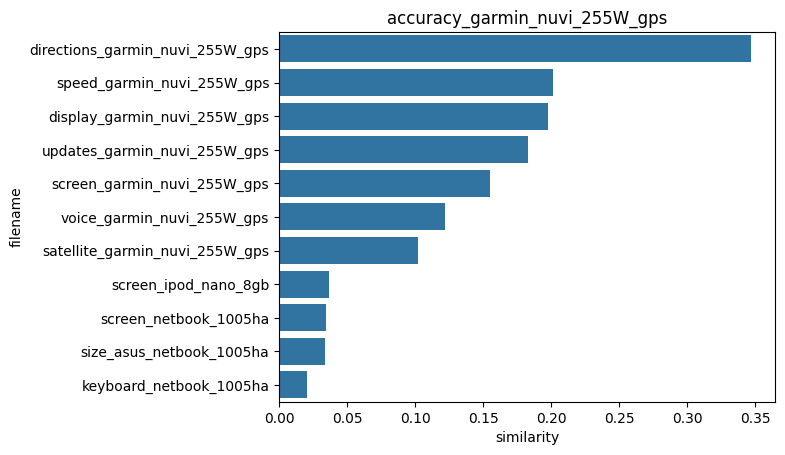

In [84]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# argsort()를 이용하여 앞예제의 첫번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 반환하되 자기 자신은 제외.
sorted_index = similarity_pair.argsort()[:,::-1]
sorted_index = sorted_index[:, 1:]

# 유사도가 큰 순으로 hotel_indexes를 추출하여 재 정렬.
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 유사도가 큰 순으로 정렬된 Index와 유사도값을 이용하여 파일명과 유사도값을 Seaborn 막대 그래프로 시각화
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value

fig1 = plt.gcf()
sns.barplot(x='similarity', y='filename',data=hotel_1_sim_df)
plt.title(comparison_docname)

# **09 한글 텍스트 처리 - 네이버 영화 평점 감성 분석**

**한글 NLP 처리의 어려움**

In [85]:
import pandas as pd

train_df = pd.read_csv('ratings_train.txt', sep='\t')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [86]:
train_df['label'].value_counts( )

,count
label,
0,75173
1,74827


In [87]:
import re

train_df = train_df.fillna(' ')
# 정규 표현식을 이용하여 숫자를 공백으로 변경(정규 표현식으로 \d 는 숫자를 의미함.)
train_df['document'] = train_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )

# 테스트 데이터 셋을 로딩하고 동일하게 Null 및 숫자를 공백으로 변환
test_df = pd.read_csv('ratings_test.txt', sep='\t')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )

# id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [88]:
!pip install konlpy
from konlpy.tag import Twitter

twitter = Twitter()
def tw_tokenizer(text):
    # 입력 인자로 들어온 text 를 형태소 단어로 토큰화 하여 list 객체 반환
    tokens_ko = twitter.morphs(text)
    return tokens_ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 30.3 MB/s eta 0:00:00


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Twitter 객체의 morphs( ) 객체를 이용한 tokenizer를 사용. ngram_range는 (1,2)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1,2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

In [90]:
# Logistic Regression 을 이용하여 감성 분석 Classification 수행.
lg_clf = LogisticRegression(random_state=0, solver='liblinear')

# Parameter C 최적화를 위해 GridSearchCV 를 이용.
params = { 'C': [1 ,3.5, 4.5, 5.5, 10 ] }
grid_cv = GridSearchCV(lg_clf , param_grid=params , cv=3 ,scoring='accuracy', verbose=1 )
grid_cv.fit(tfidf_matrix_train , train_df['label'] )
print(grid_cv.best_params_ , round(grid_cv.best_score_,4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


In [91]:
from sklearn.metrics import accuracy_score

# 학습 데이터를 적용한 TfidfVectorizer를 이용하여 테스트 데이터를 TF-IDF 값으로 Feature 변환함.
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

# classifier 는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용
best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)

print('Logistic Regression 정확도: ',accuracy_score(test_df['label'],preds))

Logistic Regression 정확도:  0.86172
